# Import

In [19]:
import sys
from pathlib import Path

qml_code_dir = Path.cwd().parent
sys.path.append(str(qml_code_dir))

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import make_circles

from moduli.preprocessing_dataset.preprocessing_dataset import preprocessa_dataset
from moduli.qsvm.qsvm import costruisci_qsvm
from moduli.kernel import kernel_amplitude
from moduli.kernel import kernel_angle
from moduli.kernel import kernel_basis
from moduli.kernel import kernel_IQP

import itertools

# Configurazione

In [20]:
# Numero di campioni da estrarre dal dataset totale.

numero_campioni = 200

# Rapporti con cui dividere il numero di campioni estratti fra il set per il training, quello per la validazione e quello per il test.

frazione_dati_per_train = 0.70
frazione_dati_per_val = 0.15
frazione_dati_per_test = 0.15

# Numero di features da utilizzare.

numero_features = 2

# Creazione o importazione dei dataset

I dataset da utilizzare vanno scompattati qui, dato che possono provenire da fonti differenti ed essere salvati in formati differenti, quindi ognuno va trattato come un caso a sé stante. Alla funzione di preprocessing va passato il dataset nella forma dataset_scelto = (X, y) dove X sono i campioni e y sono i target, ovvero (dato che abbiamo a che fare con un classificatore), 0 e 1. 

## breast_cancer

In [21]:
X_dataset_breast_cancer = load_breast_cancer().data
y_dataset_breast_cancer = load_breast_cancer().target

dataset_breast_cancer = (X_dataset_breast_cancer, y_dataset_breast_cancer)

## make_circles

In [22]:
X_make_circles, y_make_circles = make_circles(n_samples = 5000, noise = 0.1, factor = 0.3, random_state = 1)
dataset_make_circles = (X_make_circles, y_make_circles)

# Preprocessing

Nella fase di preprocessing del dataset:

- estraiamo il numero di campioni, dal totale, che vogliamo utilizzare;
- dividiamo i dati in tre set (training, validation, test);
- applichiamo la PCA.

In [23]:
dataset_scelto = dataset_make_circles

set_preparato = preprocessa_dataset(
    dataset_scelto = dataset_scelto,
    numero_campioni = numero_campioni,
    frazione_dati_per_train = frazione_dati_per_train,
    frazione_dati_per_val = frazione_dati_per_val,
    frazione_dati_per_test = frazione_dati_per_test,
    numero_features = numero_features
)


PREPROCESSING DATASET

Il numero di campioni da estrarre desiderato è valido.
I rapporti scelti sono validi.
Il numero di features richiesto, 2, è uguale alla quantità totale di features presenti nel dataset.
PCA eseguita con successo. Informazione conservata: 100.00%
Preprocessing del dataset completato.



# Addestramento, validazione e test delle QSVM

Ogni encoding ha una prima sezione dove devono essere inseriti gli iperparametri, quantistici (cioè dal cui valore dipende il calcolo del kernel quantistico e/o l'adattamento dei dati ai vari kernel) e classici (relativi al calcolo, classico, della SVM). Se non si hanno iperparametri da inserire, siano essi quantistici o classici, bisogna mettere {}. Nella fase di validazione verranno controllate tutte le possibili combinazioni di iperparametri (la barra di avanzamento è calcolata sul totale delle combinazioni possibili, riportato di fianco ad essa), per trovare quale modello, relativo ad una specifica famiglia di encoding, funziona meglio. Una volta trovato questo modello, esso viene testato. Nel notebook verrà visualizzato soltanto l'output del modello migliore, mentre verrà salvato, nella cartella "risultati_run", tutto lo storico dei vari modelli e di come hanno performato durante la fase di validazione. L'output di "costruisci_qsvm" è composto dal modello migliore trovato e dal dataset, adattato, che è stato utilizzato per allenarlo. 

## Amplitude Encoding

### Iperparametri dell'encoding

In [24]:
# Iperparametri quantistici: None.

iperparametri_quantistici_amplitude = {}

# Iperparametri classici.

iperparametri_classici_amplitude = {"C": [1.0, 10.0, 100.0, 1000.0]} 

### QSVM

QUANTUM SUPPORT VECTOR MACHINE PER AMPLITUDE ENCODING

Destinazione output: risultati_run/20260629/20260629_155636/amplitude_encoding_20260629_155636


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 4/4


Miglior iperparametro classico per C: 1.0
F1-Score (Macro) del miglior modello sul validation set: 53.12%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   38.46%    │  33.33%  │   35.71%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   41.18%    │  46.67%  │   43.75%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   39.82%    │  40.00%  │   39.73%   │              30               │
╘═══════════════╧═════════════╧══════════╧════════════╧═══════════════════════════════╛


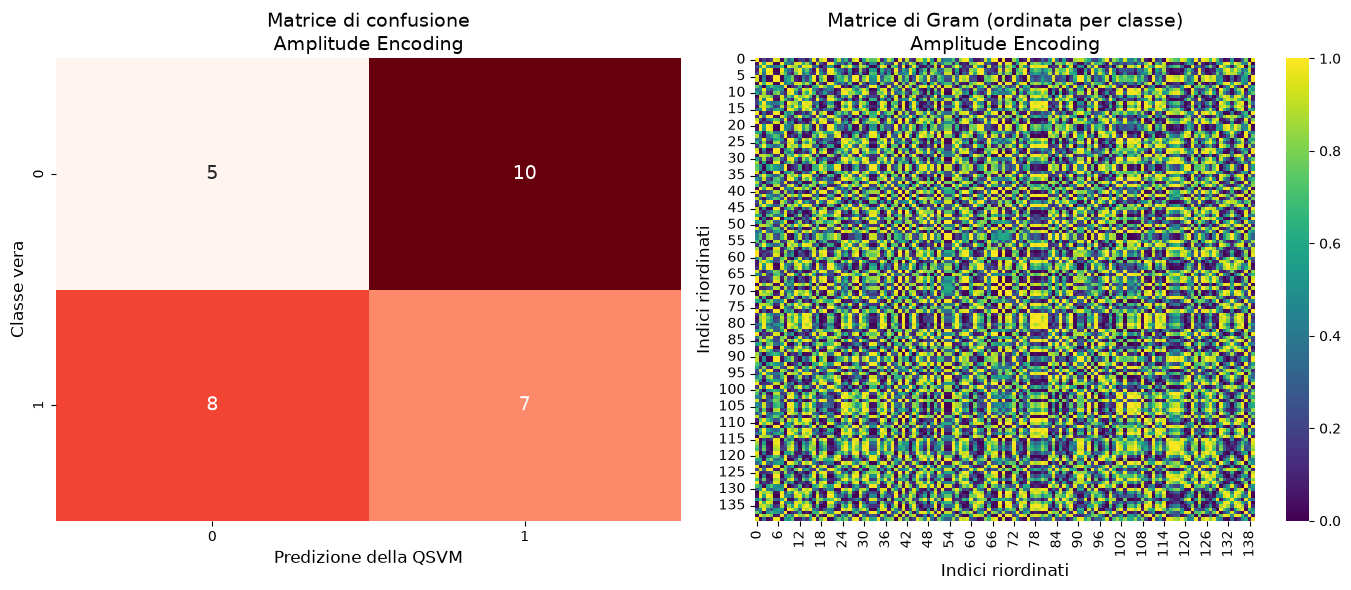

In [25]:
modello_amplitude, set_adattato_amplitude = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_amplitude,
    iperparametri_quantistici = iperparametri_quantistici_amplitude,
    iperparametri_classici = iperparametri_classici_amplitude
)

## Angle Encoding

### Iperparametri dell'encoding

In [26]:
# Iperparametri quantistici: None.

iperparametri_quantistici_angle = {}

# Iperparametri classici.

iperparametri_classici_angle = {"C": [1.0, 10.0, 100.0, 1000.0]} 

### QSVM

QUANTUM SUPPORT VECTOR MACHINE PER ANGLE ENCODING

Destinazione output: risultati_run/20260629/20260629_155636/angle_encoding_20260629_155636


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 4/4


Miglior iperparametro classico per C: 1.0
F1-Score (Macro) del miglior modello sul validation set: 100.00%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   100.00%   │ 100.00%  │  100.00%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   100.00%   │ 100.00%  │  100.00%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   100.00%   │ 100.00%  │  100.00%   │              30               │
╘═══════════════╧═════════════╧══════════╧════════════╧═══════════════════════════════╛


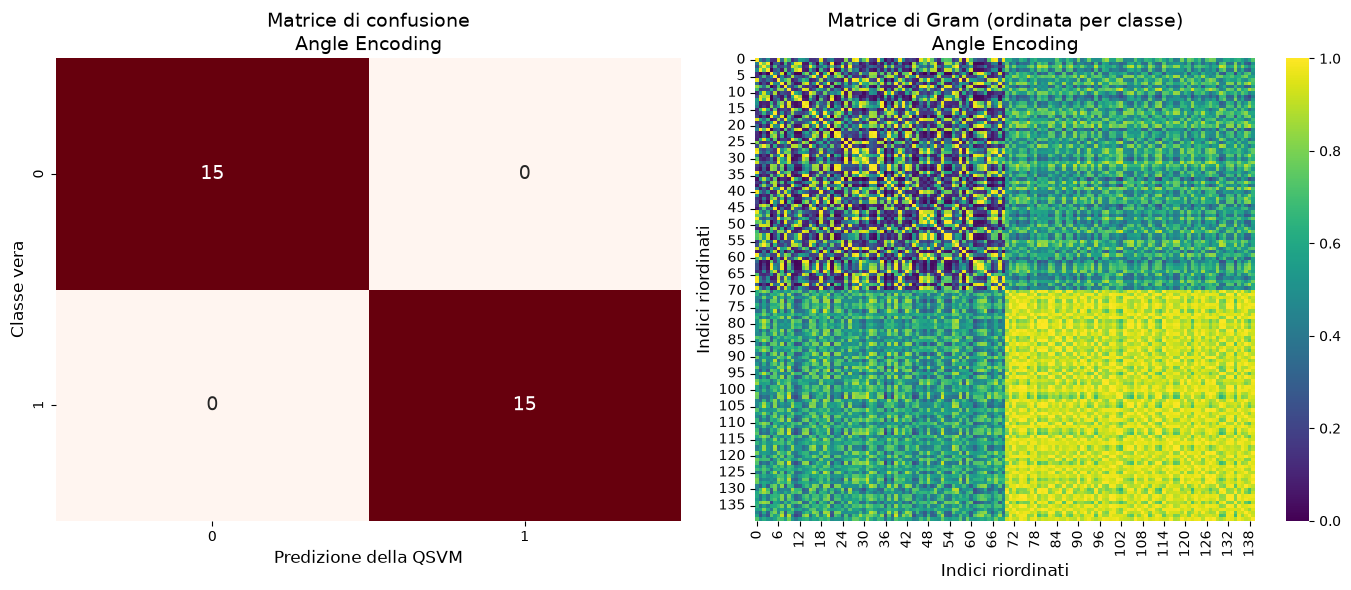

In [27]:
modello_angle, set_adattato_angle = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_angle,
    iperparametri_quantistici = iperparametri_quantistici_angle,
    iperparametri_classici = iperparametri_classici_angle
)

## Basis Encoding

### Iperparametri dell'encoding

In [28]:
# Iperparametri quantistici: "tau_bit_per_feature" (con che precisione discretizziamo le misure reali delle varie features dei campioni).

iperparametri_quantistici_basis = {"tau_bit_per_feature": [2, 3, 4, 5]} 

# Iperparametri classici.

iperparametri_classici_basis = {"C": [1.0, 10.0, 100.0, 1000.0]} 

### QSVM 

QUANTUM SUPPORT VECTOR MACHINE PER BASIS ENCODING

Destinazione output: risultati_run/20260629/20260629_155636/basis_encoding_20260629_155636


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 16/16


Miglior iperparametro quantistico per tau_bit_per_feature: 3
Miglior iperparametro classico per C: 1.0
F1-Score (Macro) del miglior modello sul validation set: 93.30%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   88.24%    │ 100.00%  │   93.75%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   100.00%   │  86.67%  │   92.86%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   94.12%    │  93.33%  │   93.30%   │              30               │
╘═══════════════╧═════════════╧══════════╧════════════╧═══════════════════════════════╛


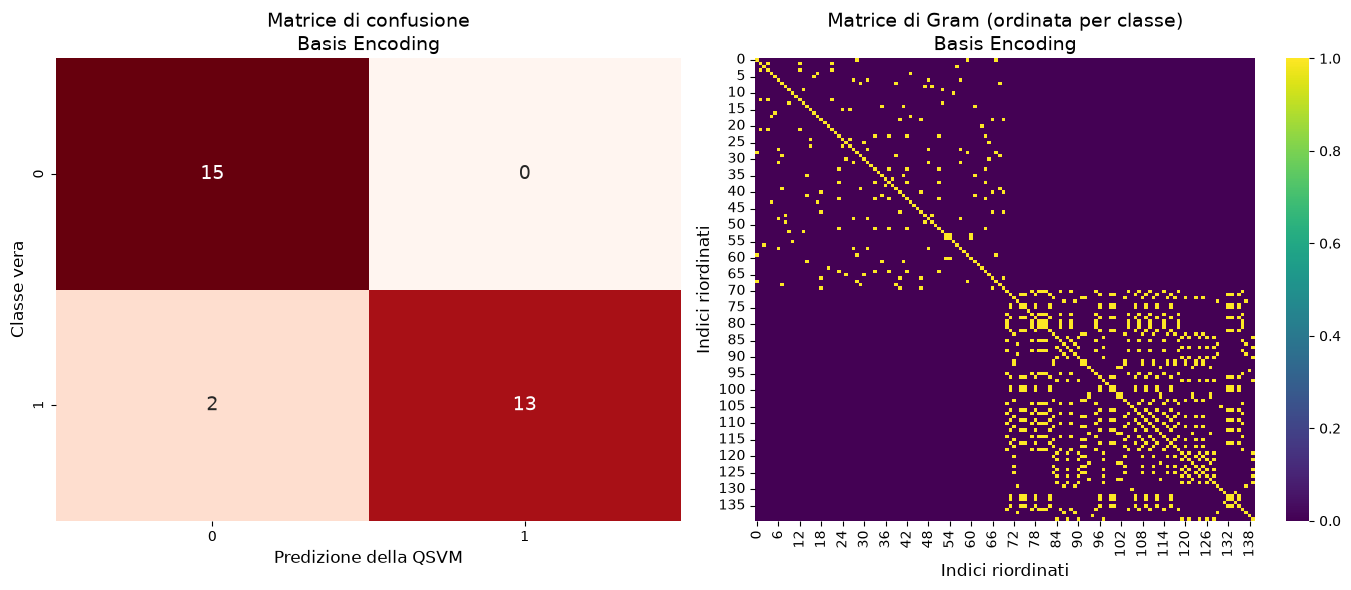

In [29]:
modello_basis, set_adattato_basis = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_basis,   
    iperparametri_quantistici = iperparametri_quantistici_basis,
    iperparametri_classici = iperparametri_classici_basis
)

## IQP Encoding

### Iperparametri dell'encoding

In [30]:
# Creazione dei pattern con cui entanglare le features nell'IQP Encoding, cioè dell'iperparametro "pattern". 

pattern_catena = [[i, i + 1] for i in range(numero_features - 1)] # Catena.
pattern_anello = [[i, i + 1] for i in range(numero_features - 1)] + [[numero_features - 1, 0]] # Anello (come catena, ma poi chiude alla fine).
pattern_tutti = [list(coppia) for coppia in itertools.combinations(range(numero_features), 2)] # Connessione totale (l'1 col 2 e col 3, il 2 col 3 e così via).

# Iperparametri quantistici: "numero_ripetizioni" (quante volte si ripete il circuito quantistico), "pattern" (come vengono entanglati i qubits).

iperparametri_quantistici_IQP = {"numero_ripetizioni": [1, 2, 3, 4], "pattern": [pattern_catena, pattern_anello, pattern_tutti]}

# Iperparametri classici.

iperparametri_classici_IQP = {"C": [1.0, 10.0, 100.0, 1000.0]}

### QSVM

QUANTUM SUPPORT VECTOR MACHINE PER IQP ENCODING

Destinazione output: risultati_run/20260629/20260629_155636/iqp_encoding_20260629_155636


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 48/48


Miglior iperparametro quantistico per numero_ripetizioni: 1
Miglior iperparametro quantistico per pattern: [[0, 1]]
Miglior iperparametro classico per C: 10.0
F1-Score (Macro) del miglior modello sul validation set: 100.00%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   100.00%   │ 100.00%  │  100.00%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   100.00%   │ 100.00%  │  100.00%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   100.00%   │ 100.00%  │  100.00%   │              30               │
╘═══════════════╧═════════════╧════════

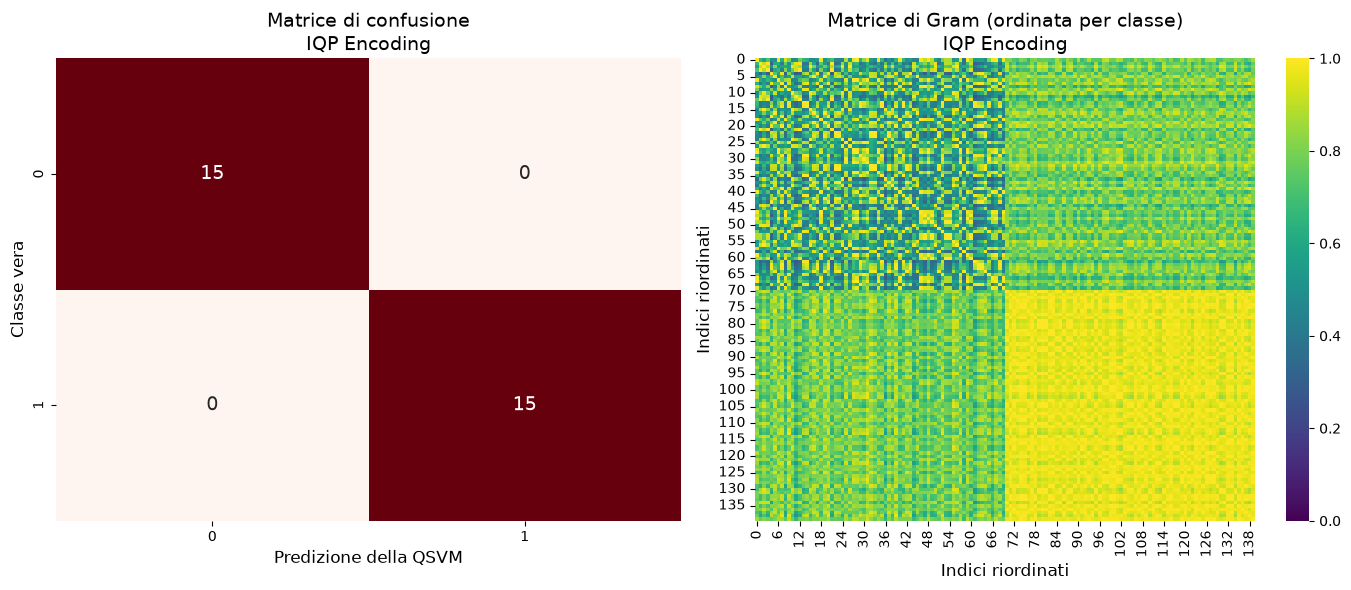

In [31]:
modello_IQP, set_adattato_IQP = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_IQP,
    iperparametri_quantistici = iperparametri_quantistici_IQP,
    iperparametri_classici = iperparametri_classici_IQP
)